# CW_11
# The Radon Transform

In this notebook you are going to look at the Radon transform and how it can be used to reconstruct a 2D object from 1D measurements. To do this, you will take the Shepp-Logan phantom, a classic brain-analogue used in CT imaging, and create a series of 1D projections of the image. Then, you will try implementing the backprojection algorithm needed to recover the original 2D object with and without spectral filtering and compare the two approaches.

In [2]:
# - No modification necessary -

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import rotate
from scipy.interpolate import interp1d

from skimage.data import shepp_logan_phantom
from skimage.transform import resize

In [84]:
# - No modification necessary -

N = 256                      # Full simulation domain size
PHANTOM_SIZE = 64            # Size of phantom before padding
NUM_ANGLES = 180             # Number of projection angles
ANGLES = np.linspace(0, 180, NUM_ANGLES, endpoint=False)

dx = 1.0

# Coordinate grids
x = np.arange(-N//2, N//2) * dx
y = np.arange(-N//2, N//2) * dx

X, Y = np.meshgrid(x, y)

# Frequency grids
fx = np.fft.fftfreq(N, d=dx)
fy = np.fft.fftfreq(N, d=dx)

FX, FY = np.meshgrid(np.fft.fftshift(fx),
                     np.fft.fftshift(fy))

omega_x = 2 * np.pi * FX
omega_y = 2 * np.pi * FY

In [85]:
# - No modification necessary -

def plot_image(image, title="", cmap="gray_r"):
    """
    Display a 2D image.
    """
    plt.figure(figsize=(6, 6))
    plt.imshow(image,
               cmap=cmap,
               extent=[x[0], x[-1], y[0], y[-1]])
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


def plot_projection(projection, title="Projection"):
    """
    Display a 1D projection.
    """
    plt.figure(figsize=(8, 4))
    plt.plot(projection)
    plt.title(title)
    plt.xlabel("Detector Coordinate")
    plt.ylabel("Integrated Intensity")
    plt.grid()
    plt.tight_layout()
    plt.show()

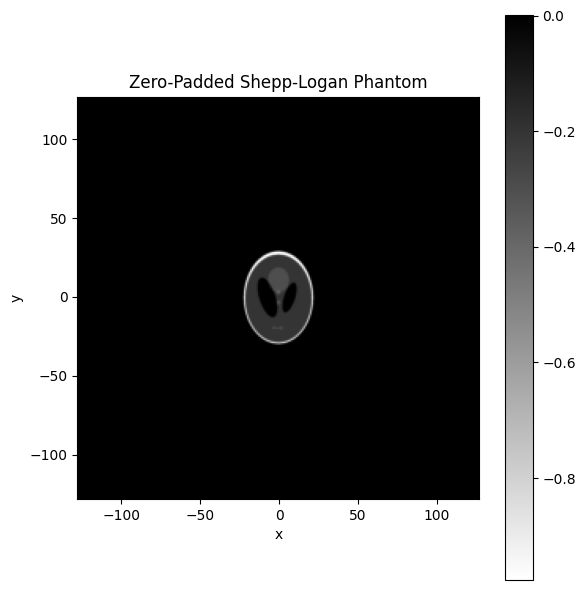

In [86]:
# - No modification necessary -

def create_phantom():
    """
    Create a zero-padded Shepp-Logan phantom.
    """

    phantom = -1 * shepp_logan_phantom()

    phantom = resize(
        phantom,
        (PHANTOM_SIZE, PHANTOM_SIZE),
        anti_aliasing=True
    )

    padded = np.zeros((N, N))

    start = N//2 - PHANTOM_SIZE//2
    end = start + PHANTOM_SIZE

    padded[start:end, start:end] = phantom

    return padded

phantom = create_phantom()

plot_image(
    phantom,
    title="Zero-Padded Shepp-Logan Phantom"
)

# Part 1

In this first part you will implement the projection algorithm used to probe the 2D object. To do this, you should rotate the image then sum along the projection axis. Implement this behavior in the function compute_projection, and then run the visualization code to verify that your results make sense.

Once you have implemented the projection function, you must take measurements along all provided angles (ANGLES) to build up a sinogram, which simply plots the 1D projections versus the angle of projection. Implement this behavior in the function compute_sinogram and then run the provided code to plot the results. (Note that the sinogram indices should be ordered as [angle, x]) 

In [87]:
def compute_projection(image, angle):
    """
    Compute Radon projection by rotating image
    and integrating along one axis.
    """

    rotated = rotate(
        image,
        angle,
        reshape=False,
        order=1
    )

    projection = np.sum(rotated, axis=0)

    return projection

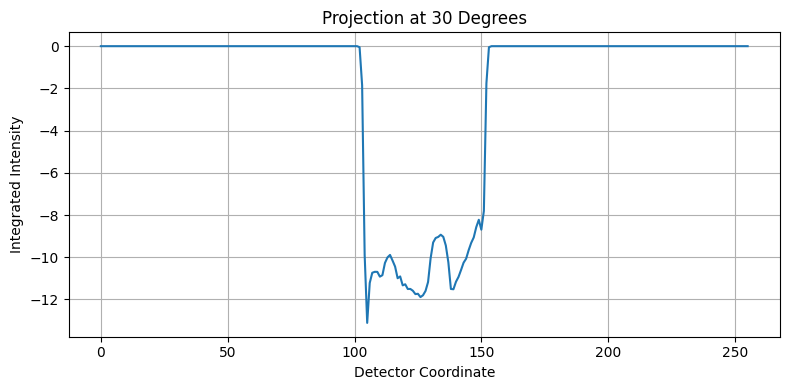

In [88]:
# - No modification necessary -

example_angle = 30

projection = compute_projection(
    phantom,
    example_angle
)

plot_projection(
    projection,
    title=f"Projection at {example_angle} Degrees"
)

In [89]:
def compute_sinogram(image, angles):
    """
    Compute projections over many angles.
    """

    sinogram = []

    for angle in angles:

        proj = compute_projection(
            image,
            angle
        )

        sinogram.append(proj)

    sinogram = np.array(sinogram)

    return sinogram

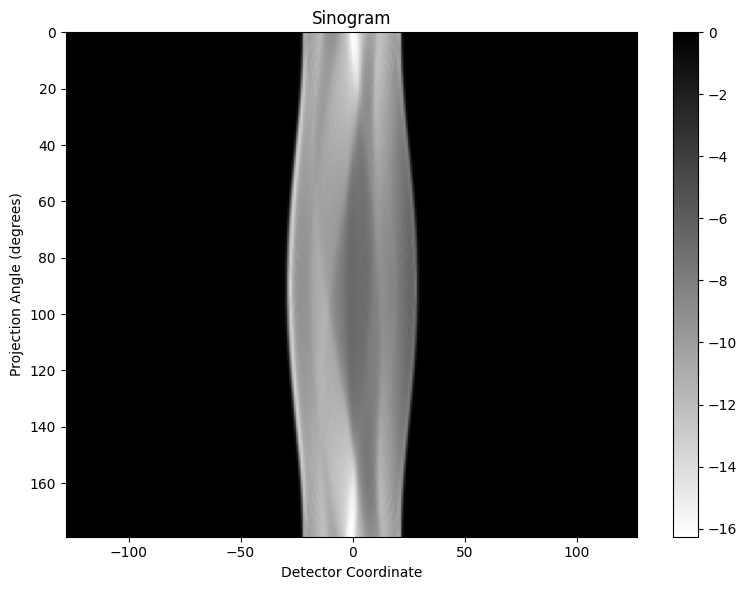

In [90]:
# - No modification necessary -

sinogram = compute_sinogram(
    phantom,
    ANGLES
)

plt.figure(figsize=(8, 6))

plt.imshow(sinogram, cmap="gray_r", aspect="auto", extent=[x[0], x[-1], ANGLES[-1], ANGLES[0]])
plt.xlabel("Detector Coordinate")
plt.ylabel("Projection Angle (degrees)")
plt.title("Sinogram")
plt.colorbar()

plt.tight_layout()
plt.show()

# Part 2

In this part of the exercise you are going to try a naïve backprojection approach to reconstruct the 2D image.

We know from the Fourier slice theorem that the Fourier transform of each of our projections corresponds to a slice of the frequency domain representation of the 2D image. 

To recreate our image, then, we must start by taking the Fourier transform of each of our 1D projections. Then for each Fourier transform, we need to use the interp1D function to rotate the array into the correct coordinates of the 2D Fourier spectrum. After doing this, we can take an inverse Fourier transform. Since the Fourier transform is linear, we do each inverse transform separately and then sum after to retrieve our original image.

Implement this behavior in the simple_backprojection function and use the provided visualization code to check if you have successfully reconstructed the object.

In [91]:
def simple_backprojection(sinogram, angles):
    """
    Reconstruct image using naive backprojection.
    """

    reconstruction = np.zeros((N, N))

    Xc, Yc = np.meshgrid(
        np.arange(-N//2, N//2),
        np.arange(-N//2, N//2)
    )

    for i, angle in enumerate(angles):

        theta = np.deg2rad(angle)

        # Detector coordinate
        t = Xc*np.cos(theta) + Yc*np.sin(theta)

        t_idx = t + N//2

        projection = sinogram[i]

        interp = interp1d(
            np.arange(N),
            projection,
            bounds_error=False,
            fill_value=0.0
        )

        backprojected = interp(t_idx)

        reconstruction += backprojected

    reconstruction *= np.pi / (2 * len(angles))

    return reconstruction

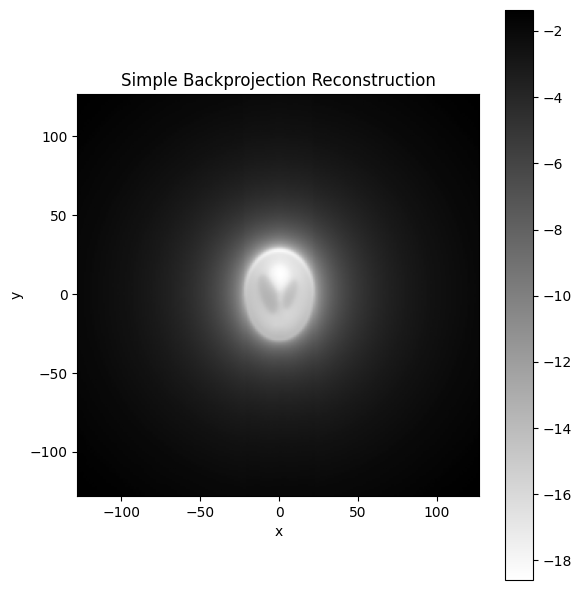

In [92]:
# - No modification necessary -

bp_reconstruction = simple_backprojection(
    sinogram,
    ANGLES
)

plot_image(
    bp_reconstruction,
    title="Simple Backprojection Reconstruction"
)

# Part 3

As you have now seen, directly backprojecting to recreate your object does not yield the highest quality results. To try to correct this, you will now implement a filtered backprojection. For this implementation, you will apply a ramp filter in the Fourier space to each projection before executing the recreation algorithm.

To begin, implement this ramp filter in the function ramp_filter. The filter should have a magnitude equal to the absolute value of the frequency. Once you have implemented this function, complete the function filter_sinogram to generate a filtered sinogram from an unfiltered one. Once you have implemented these, you can run the provided visualizations to see how your backprojection has changed.

Then, answer the following questions:
1) Try changing the number of angles that are used. Around how many do you need to get a decent reconstruction of the image using filtered backprojection? Can any amount of angles fix the unfiltered backprojection?
2) What is the ramp filter doing, and why is it necessary to get a good reconstruction?
3) We empirically observe that increasing the number of angles used monotonically improves image reconstruction quality. What are the main reasons why in a real setup we would want to limit the number of angles used?

In [93]:
def ramp_filter(projection):
    """
    Apply Ram-Lak ramp filter in Fourier space.
    """

    freqs = np.fft.fftfreq(len(projection))

    filter_kernel = np.abs(freqs)

    projection_fft = np.fft.fft(projection)

    filtered_fft = projection_fft * filter_kernel

    filtered_projection = np.real(
        np.fft.ifft(filtered_fft)
    )

    return filtered_projection

In [94]:
def filter_sinogram(sinogram):
    """
    Apply ramp filter to every projection.
    """
    filtered = []

    for proj in sinogram:
        filtered_proj = ramp_filter(proj)
        filtered.append(filtered_proj)

    return np.array(filtered)

filtered_sino = filter_sinogram(sinogram)

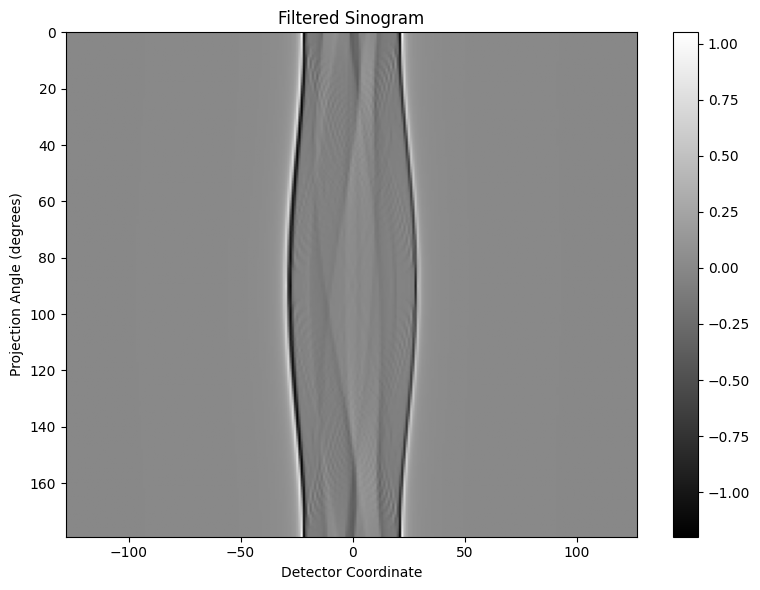

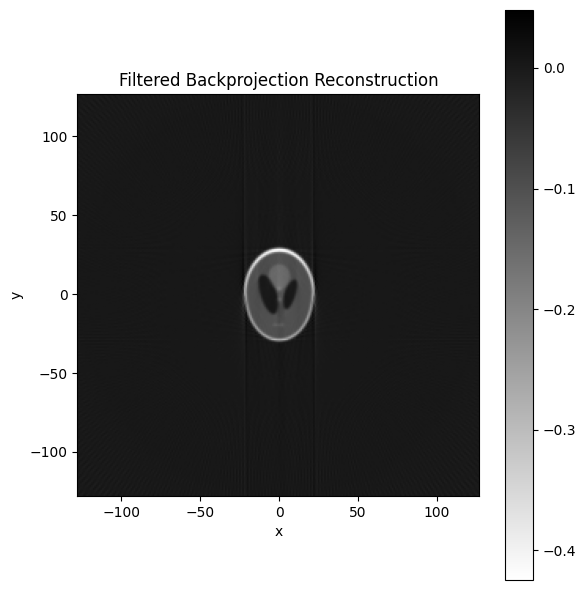

In [95]:
# - No modification necessary -

plt.figure(figsize=(8, 6))

plt.imshow(filtered_sino, cmap="gray", aspect="auto", extent=[x[0], x[-1], ANGLES[-1], ANGLES[0]])

plt.xlabel("Detector Coordinate")
plt.ylabel("Projection Angle (degrees)")
plt.title("Filtered Sinogram")
plt.colorbar()

plt.tight_layout()
plt.show()

fbp_reconstruction = simple_backprojection(
    filtered_sino,
    ANGLES
)

plot_image(
    fbp_reconstruction,
    title="Filtered Backprojection Reconstruction"
)

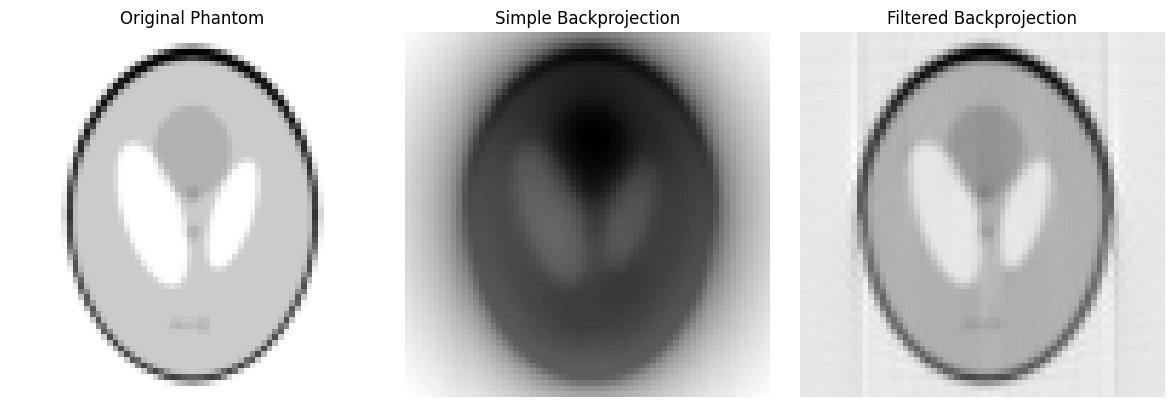

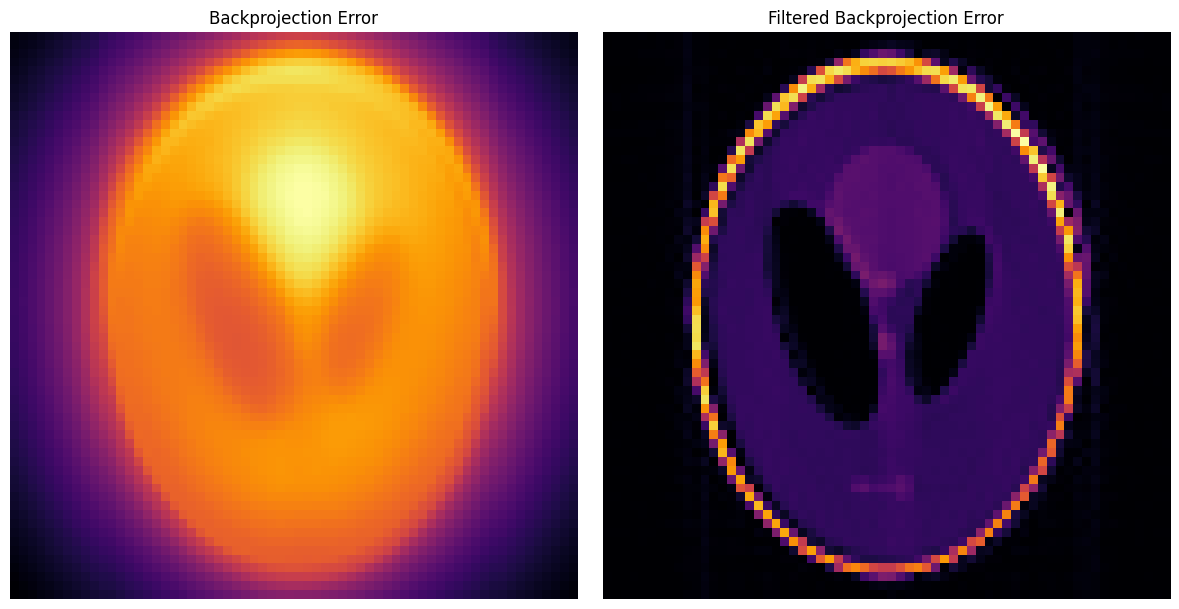

Backprojection MSE:         164.349059
Filtered Backprojection MSE: 0.015837


In [96]:
# - No modification necessary -

def crop_center(image, crop_size=PHANTOM_SIZE):
    start = N//2 - crop_size//2
    end = start + crop_size

    return image[start:end, start:end]


original_crop = crop_center(phantom)
bp_crop = crop_center(bp_reconstruction)
fbp_crop = crop_center(fbp_reconstruction)

# ------------------------------------------------------------
# Plot comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_crop, cmap="gray")
axes[0].set_title("Original Phantom")

axes[1].imshow(bp_crop, cmap="gray")
axes[1].set_title("Simple Backprojection")

axes[2].imshow(fbp_crop, cmap="gray")
axes[2].set_title("Filtered Backprojection")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# Difference Images
# ============================================================

bp_error = np.abs(original_crop - bp_crop)
fbp_error = np.abs(original_crop - fbp_crop)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(bp_error, cmap="inferno")
axes[0].set_title("Backprojection Error")

axes[1].imshow(fbp_error, cmap="inferno")
axes[1].set_title("Filtered Backprojection Error")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# Optional Quantitative Metrics
# ============================================================

bp_mse = np.mean((original_crop - bp_crop)**2)
fbp_mse = np.mean((original_crop - fbp_crop)**2)

print(f"Backprojection MSE:         {bp_mse:.6f}")
print(f"Filtered Backprojection MSE: {fbp_mse:.6f}")

## Discussion
1) After around 20 angles the filtered backprojection reconstruction becomes fairly clear. No matter how many angles we use, the unfiltered backprojection always has the background blur from low frequencies.
2) The ramp filter is used to supress low spatial frequency components in our projections. This is necessary because as we stack our lines in Fourier space, we experience more overlap in the center (DC) region than around the edges. The ramp filter approximately compensates this and prevents the low frequencies from being over-represented.
3) In the real world, the main limits we would run into would arise from time and complexity. More measurements means more time with the sample and more time to compute the results, and it also means that more space will be needed to store the information that has been measured.